# 0. Ensemble Learning - Stacking

### Objetivo: preparar e estruturar o dataset para a aplicação de um método de Stacking Ensemble, combinando os três modelos de classificação que apresentaram os melhores desempenhos no Benchmark: Regressão Logística, Linear SVM e Random Forest.

## 1: Preparação dos Dados e importações

#### Este documento é a primeira etapa do pipeline de Ensemble Learning. Ele abrange a importação de bibliotecas, carregamento do dataset, limpeza, tratamento de valores ausentes, análise exploratória (EDA), separação de variáveis, divisão entre treino/teste e a vetorização de texto via TF-IDF. Importamos todas as bibliotecas essenciais para manipulação de dados, visualização gráfica, vetorização de texto e particionamento dos dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Configurações visuais e de avisos
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento do Dataset
Carregamos o dataset bruto/limpo (`fake_recogna_limpo.csv`) para a memória a fim de iniciar a inspeção estrutural das colunas e das dimensões iniciais.

In [3]:
# Definindo o caminho e carregando o arquivo CSV
caminho_csv = r"C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\fake_recogna_limpo.csv"
df = pd.read_csv(caminho_csv)

print(f"Dimensões iniciais do DataFrame: {df.shape}")
display(df.head())

Dimensões iniciais do DataFrame: (11902, 11)


,Titulo,Subtitulo,Noticia,Categoria,Data,Autor,URL,Classe,texto_bruto,texto_limpo,num_palavras
0,\n\nPapa Francisco foi preso sob acusação de t...,Boato – Ocorreu um apagão no Vaticano. O papa ...,apagão vaticano papar presar acusação tráfico ...,entretenimento,11/01/2021,\nEdgard Matsuki,https://www.boatos.org/religiao/papa-francisco...,0,\n\nPapa Francisco foi preso sob acusação de t...,papa francisco foi preso sob acusação de tráfi...,164
1,Equador prepara cova coletiva para mortos por ...,NaN,o governar equador anunciar preparar cova cole...,saúde,27/03/2020 18h25,27/03/2020 18h25,https://noticias.uol.com.br/internacional/ulti...,1,Equador prepara cova coletiva para mortos por ...,equador prepara cova coletiva para mortos por ...,80
2,Air France voltará a operar voo direto Pequim-...,NaN,o companhia air france operar voar direto pequ...,saúde,07/08/2020 13h42,07/08/2020 13h42,https://www.uol.com.br/nossa/noticias/afp/2020...,1,Air France voltará a operar voo direto Pequim-...,air france voltará a operar voo direto pequimp...,103
3,Marfrig intensifica venda de carne do Brasil a...,NaN,o marfrig global foods retomar vender carnar b...,saúde,27/04/2020 14h53,27/04/2020 14h53,https://economia.uol.com.br/noticias/reuters/2...,1,Marfrig intensifica venda de carne do Brasil a...,marfrig intensifica venda de carne do brasil a...,92
4,As parciais das eleições de 2014 alternaram ma...,NaN,o assunto voltar o compartilhar rede social ju...,entretenimento,31/07/2021,Gilmar Lopes,https://www.e-farsas.com/as-parciais-das-eleic...,0,As parciais das eleições de 2014 alternaram ma...,as parciais das eleições de alternaram mais de...,48


## 3. Limpeza e Tratamento de Valores Ausentes
Verificamos a existência de valores nulos (`NaN`) e registros duplicados. Em seguida, removemos essas instâncias para garantir a integridade dos dados textuais e dos rótulos de classe.

In [4]:
# Verificando a contagem de valores nulos por coluna
print("Valores nulos antes da limpeza:")
print(df[['texto_limpo', 'Classe']].isnull().sum())

# Verificando registros duplicados
print(f"\nQuantidade de linhas duplicadas: {df.duplicated().sum()}")

# Removendo duplicadas e descartando linhas onde o texto_limpo ou a Classe sejam nulos
df = df.drop_duplicates().dropna(subset=['texto_limpo', 'Classe'])

print(f"\nDimensões após a limpeza e remoção de nulos: {df.shape}")

Valores nulos antes da limpeza:
texto_limpo    0
Classe         0
dtype: int64

Quantidade de linhas duplicadas: 0

Dimensões após a limpeza e remoção de nulos: (11902, 11)


## 4. Análise Exploratória de Dados (EDA)
Realizamos uma análise visual da distribuição das classes (notícias falsas vs. verdadeiras) e do tamanho dos textos (em quantidade de palavras) para entender melhor o comportamento do corpus.

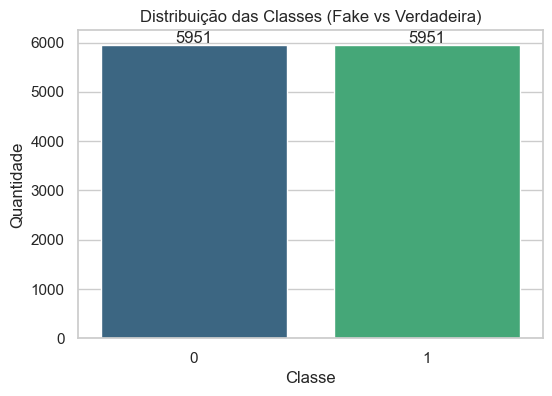

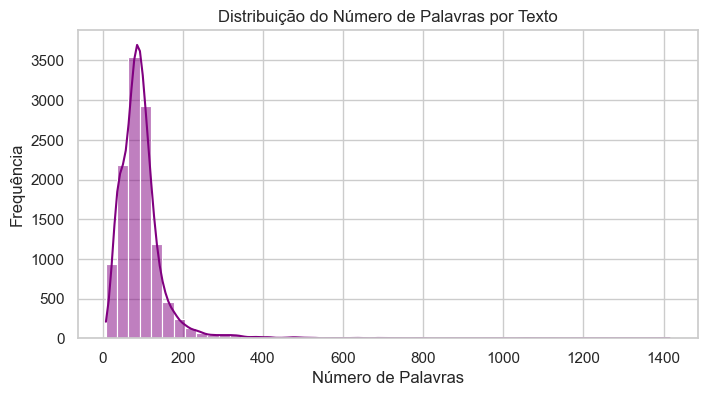

In [5]:
# 1. Gráfico de distribuição das classes
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Classe', palette='viridis')
plt.title('Distribuição das Classes (Fake vs Verdadeira)')
plt.xlabel('Classe')
plt.ylabel('Quantidade')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

# 2. Distribuição do número de palavras por texto (calculando na hora para evitar erros)
df['num_palavras'] = df['texto_limpo'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 4))
sns.histplot(df['num_palavras'], bins=50, kde=True, color='purple')
plt.title('Distribuição do Número de Palavras por Texto')
plt.xlabel('Número de Palavras')
plt.ylabel('Frequência')
plt.show()

## 5. Separação das Variáveis Preditoras (X) e Alvo (y)
Separamos o texto descritivo (recurso de entrada) da coluna de rótulo (0 ou 1, falso ou verdadeiro).

In [6]:
# Definindo X (recursos/textos) e y (alvo/labels)
X = df['texto_limpo']
y = df['Classe']

print(f"Total de amostras em X: {X.shape[0]}")
print(f"Total de amostras em y: {y.shape[0]}")

Total de amostras em X: 11902
Total de amostras em y: 11902


## 6. Divisão Treino/Teste
Dividimos o conjunto de dados em subconjuntos de Treino (80%) e Teste (20%), aplicando estratificação para garantir que a proporção das classes seja mantida em ambos os subconjuntos.

In [7]:
# Divisão estratificada dos dados
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Tamanho do conjunto de Treino (bruto): {X_train_raw.shape[0]}")
print(f"Tamanho do conjunto de Teste (bruto): {X_test_raw.shape[0]}")

Tamanho do conjunto de Treino (bruto): 9521
Tamanho do conjunto de Teste (bruto): 2381


## 7. Vetorização TF-IDF
Convertemos os textos em matrizes numéricas utilizando o `TfidfVectorizer`. O vetorizador é ajustado (`fit_transform`) estritamente nos dados de treino para evitar vazamento de dados (*data leakage*) e aplicado via transformação (`transform`) nos dados de teste.

Formato da matriz TF-IDF de Treino: (9521, 5000)
Formato da matriz TF-IDF de Teste: (2381, 5000)

Documento 01 concluído! Vetorizador e splits salvos com sucesso.


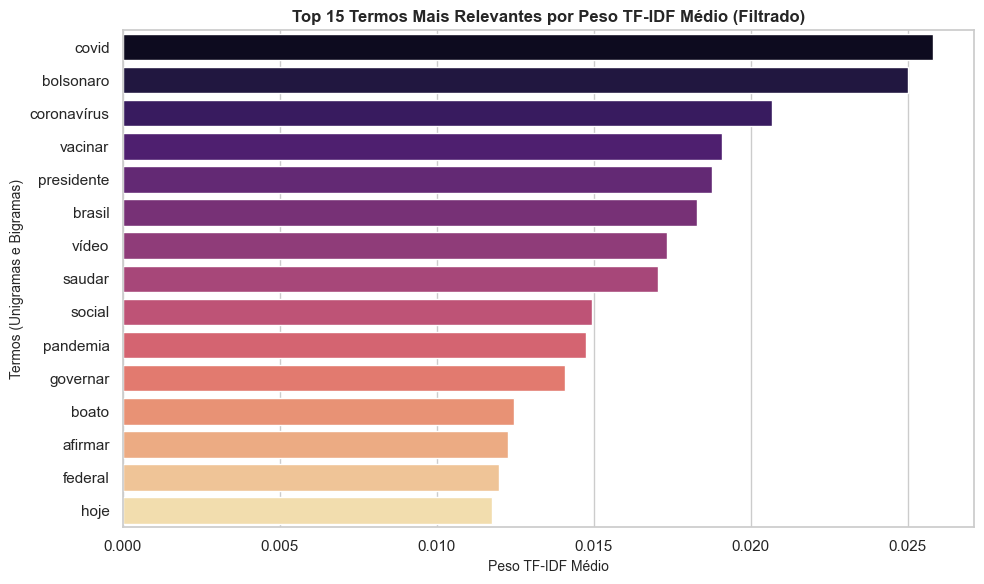

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Lista personalizada de stopwords em português para garantir a limpeza
stopwords_pt = [
    'de', 'que', 'em', 'do', 'da', 'dia', 'um', 'para', 'é', 'com', 'não', 
    'uma', 'os', 'no', 'se', 'na', 'por', 'mais', 'as', 'dos', 'como', 'mas', 
    'foi', 'ao', 'ele', 'das', 'tem', 'à', 'seu', 'sua', 'ou', 'ser', 'quando', 
    'muito', 'há', 'nos', 'já', 'está', 'eu', 'também', 'só', 'pelo', 'pela' 
    'até', 'isso', 'ela', 'entre', 'depois', 'sem', 'mesmo', 'aos', 'suas', 'seria', 'ano', 'pessoa', 'país', 'haver', 'paulo'
]

# Instanciando o Vetorizador TF-IDF com filtros para eliminar stopwords e termos muito frequentes
tfidf = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 2),
    stop_words=stopwords_pt,  # Remove a lista de palavras vazias
    max_df=0.85               # Ignora palavras que aparecem em mais de 85% dos documentos (como 'de', 'que', etc.)
)

# Ajustando e transformando o treino
X_train = tfidf.fit_transform(X_train_raw)

# Transformando apenas o teste
X_test = tfidf.transform(X_test_raw)

print(f"Formato da matriz TF-IDF de Treino: {X_train.shape}")
print(f"Formato da matriz TF-IDF de Teste: {X_test.shape}")

# Criando pastas necessárias e salvando os artefatos processados
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
joblib.dump((X_train, X_test, y_train, y_test), '../data/processed/dados_split.pkl')

print("\nDocumento 01 concluído! Vetorizador e splits salvos com sucesso.")

# ==========================================
# GRÁFICO: Top 15 Termos Mais Relevantes (Sem Stopwords)
# ==========================================
feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.asarray(X_train.mean(axis=0)).ravel()

df_tfidf = pd.DataFrame({'termo': feature_names, 'peso_medio': mean_tfidf})
df_top15 = df_tfidf.sort_values(by='peso_medio', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_top15, x='peso_medio', y='termo', palette='magma')
plt.title('Top 15 Termos Mais Relevantes por Peso TF-IDF Médio (Filtrado)', fontsize=12, fontweight='bold')
plt.xlabel('Peso TF-IDF Médio', fontsize=10)
plt.ylabel('Termos (Unigramas e Bigramas)', fontsize=10)
plt.tight_layout()
plt.show()